In [1]:
from taxutils import taxutils

If you haven't added the environment variable to your .bashrc/.zshrc so it loads automatically (export TAXUTILS_GLOBALS=/path/to/taxutils/saves), you can set it in your script with os instead. I recommend you set the variable in your zshrc/bashrc (`export TAXUTILS_GLOBALS=/path/to/taxutils/saves`) so that the same files can be used for any future projects, reducing the number of redundant copies of these files.

In [2]:
# os.environ["TAXUTILS_GLOBALS"] = "/path/to/your/taxutils/cache"

Load the taxonomic utils object, queing the downloading sequence and data loading. The accessions to taxa map is quite large (there are a lot of accessions). A hash map is the fastest lookup, but loading the entirety of the database would clog our active memory. We can instead build a Sqlite db once, allowing us to get quick queries later on. This build takes about 10-20 minutes and consumes ~25gb of disk space, but subsequent lookups will be much more efficient for impatient users like myself. If we opt out of the db build (by default) we will search through the `nucl_gb.accession2taxid.gz` for the relevant accessions and build the unordered map once in memory. This is much slower, but can save you that disk space if needed.

In [3]:
tu = taxutils(low_memory=False, rebuild=False)
tu

2026-06-15 22:26:05,127 | INFO : names.dmp and nodes.dmp exist in $TAXUTILS_GLOBALS (/shares/swabseq/trident_globals), skipping download.
2026-06-15 22:26:05,129 | INFO : Building nodes...
2026-06-15 22:27:32,971 | INFO : /shares/swabseq/trident_globals/nucl_gb.accession2taxid.gz already exists, skipping download.


TaxonomicUtils(
  names=dict(2726603 entries),
  nodes=DataFrame,
  target_taxa=list(186867 items),
  a2t=None,
  parent=dict(2726602 entries),
  methods=['format_tree', 'get_branch', 'get_distance', 'get_lca', 'get_rank_order', 'get_subtree', 'get_t2a', 'higher_than_rank', 'load_a2t', 'parse_accession', 'sort_taxa', 'topology']
)

## Accessions to taxa, and back

There are more than a few tools that rely on accession to taxid mappings, and they often require you to painfully create these maps yourself. They might ask you to change the header names in your fastas to adhere to their desired format. Spending more than 10 minutes on a painfully tedious task like that is enough to drive me into an impatient rage. To work around this issue, a convenient parser for a large variety of possible inputs is available to extract the accession IDs from headers. You can then load their associated taxids into a map (`tu.a2t`), and carry out your task (rewrite the header, create your map .txt file, etc). Your skillful hand (or LLM, probably) should be able to take it from here.

In [4]:
headers = []
with open("eg.fasta") as f:
  for line in f:
      if line.startswith(">"):
          headers.append(line.strip())

# parse strings containing accession IDs as a list, array, series, or individual accession
acc_ids = tu.parse_accession(headers, version=True)

`load_a2t` loads the subset of accessions you need, rather than the entire possible nucl_gb.accession2taxid.gz dataset, since that would consume a ton of RAM. With low memory off, this is extremely quick as it relies on the pre-built sqlite db (that you will have to build at least once, stored in your globals, forever, until you redownload the latest data every X months).

In [5]:
tu.load_a2t(acc_ids)

2026-06-15 22:27:34,771 | INFO : /shares/swabseq/trident_globals/nucl_gb.accession2taxid.gz already exists, skipping download.


In [6]:
for a, t in tu.a2t.items():
    print(tu.names[tu.a2t[a]] + f" ({t})") # access the a2t map, and use tu.names to get the associated name of each taxon

SARS-CoV-2 (2697049)
Metamycoplasma hominis (2098)
Human betacoronavirus 2c EMC/2012 (1235996)
Escherichia phage phiX174 (2886930)


We might also want the accessions associated with taxa. For instance, we might want to find all the accessions that belong to Enterovirus (10259). There are apparently 63 of them, at the moment:

In [7]:
len(tu.get_t2a([12059]))

63

Or, we might want the entire Enterovirus subtree:

In [8]:
len(tu.get_t2a(tu.get_subtree(12059)))

143132

### (and back) t2a

You might want the accessions of a specific branch of Enterovirus, rather than the whole subtree. Let try to find the accessions for Rhinovirus C22, its subtree, and its parent branch up to Enterovirus. I am lazy and don't want to search the internet or wait for an LLM to potentially give the wrong taxon, so I'll use taxutils object to find it instead:

In [9]:
tu.nodes["name"] = tu.nodes["taxon"].map(tu.names) # add names to nodes so we can use vectorized string operations

In [10]:
rvc22 = tu.nodes[tu.nodes.name.str.lower().str.contains("rhinovirus c22")]
display(rvc22)

,taxon,parent,rank,rank_code,rank_base,rank_idx,new_rank,name
1125649,1418070,463676,no rank,S3,S,9,species,rhinovirus C22


In [11]:
rvc22_to_ev = set(tu.get_branch(rvc22.taxon.item())) - set(tu.get_branch(12059))
# We can see the sorted branch in order if the set operations changed it
# (I like to use this for plots) 
tu.sort_taxa(rvc22_to_ev)

[3428504, 463676, 1418070]

In [12]:
rvc22_to_ev.update(tu.get_subtree(1418070))
tu.sort_taxa(rvc22_to_ev)

[3428504, 463676, 1418070]

Turns out, Rhinovirus C22 is a leaf node and has nothing in the subtree to add. Now we can call the accessions of each of these taxa:

In [13]:
len(tu.get_t2a(rvc22_to_ev))

7288

## Examining rank

The NCBI taxonomic ranks are imperfect. To exhibit this fact and to see the correction we make, we can filter for mismatches:

In [14]:
tu.nodes["name"] = tu.nodes["taxon"].map(tu.names)
mismatches = tu.nodes[tu.nodes["new_rank"] != tu.nodes["rank"]]

In [15]:
mismatches.head(5)

,taxon,parent,rank,rank_code,rank_base,rank_idx,new_rank,name
0,1,1,no rank,R,R,1,root,root
124,161,160,subspecies,S2,S,9,species,Treponema pallidum subsp. pallidum
131,168,160,subspecies,S2,S,9,species,Treponema pallidum subsp. pertenue
137,176,173,no rank,S2,S,9,species,Leptospira interrogans serovar Hardjo
207,264,263,subspecies,S2,S,9,species,Francisella tularensis subsp. novicida


Take taxon 176, for example, which is not assigned a rank by default. What rank, if any, are its parent's assigned? We can get its parent branch, and look those taxa ranks:

In [16]:
branch = tu.get_branch(176)

tu.nodes.loc[
  tu.nodes["taxon"].isin(branch)
].set_index("taxon").loc[branch].reset_index()

,taxon,parent,rank,rank_code,rank_base,rank_idx,new_rank,name
0,1,1,no rank,R,R,1,root,root
1,131567,1,cellular root,R2,R,1,root,cellular organisms
2,2,131567,domain,D,D,2,domain,Bacteria
3,3379134,2,kingdom,K,K,3,kingdom,Pseudomonadati
4,203691,3379134,phylum,P,P,4,phylum,Spirochaetota
5,203692,203691,class,C,C,5,class,Spirochaetia
6,1643688,203692,order,O,O,6,order,Leptospirales
7,170,1643688,family,F,F,7,family,Leptospiraceae
8,171,170,genus,G,G,8,genus,Leptospira
9,173,171,species,S,S,9,species,Leptospira interrogans


Clearly then, we have a case wher 176 should be some rank assignment below species, as its direct parent 171 is species, and yet it is assigned without rank. These inconsistencies can lead to weird bugs if you perform any analysis that looks at rank, using the given hierarchy. Our correction gives this a rank_code of S2 (one below S).

## Tree queries

I'm often curious to figure out the relationship between two taxa in the tree, or to get some specific subset of the tree. These functions are helpful: `get_lca`, `higher_than_rank`, `get_subtree`, `get_branch`. The last two have already been introduced in this walkthrough. I have on occasion been interested in analyzing a specific rank of the tree. For instance, here is the percentage of nodes that fall below Family ranking:

In [17]:
(~tu.higher_than_rank(tu.nodes["taxon"], "F")).sum() / tu.nodes.shape[0]

np.float64(0.9965235116823064)

Or, the cumulative percentage at each rank:

In [18]:
rank_to_name = dict(zip(tu.nodes["rank_base"], tu.nodes["new_rank"]))
for rank in tu.get_rank_order(): # or, not in order, tu.nodes.rank_base.unique()
    print(rank + f" ({rank_to_name.get(rank)}): " + str((~tu.higher_than_rank(tu.nodes["taxon"], rank)).sum() / tu.nodes.shape[0]))

U (None): 1.0
R (root): 1.0
D (domain): 0.999971026207712
K (kingdom): 0.9998587986072042
P (phylum): 0.9998250569756789
C (class): 0.999456466326952
O (order): 0.998716350974583
F (family): 0.9965235116823064
G (genus): 0.9873278168210835
S (species): 0.9241521131430256


We can put some of the earlier functions together to tie two rhinovirus nodes together in the tree, using `get_lca`:

In [19]:
rv_c = tu.nodes[
    tu.nodes["name"].str.lower().str.contains("rhinovirus c", na=False)
]

taxon_a = rv_c.iloc[1]["taxon"]
taxon_b = rv_c.iloc[-1]["taxon"]

branch_a = tu.get_branch(taxon_a)
branch_b = tu.get_branch(taxon_b)
lca = tu.get_lca(taxon_a, taxon_b)

branch_taxa = tu.sort_taxa(set(branch_a) | set(branch_b))

branch_df = (
  tu.nodes.loc[tu.nodes["taxon"].isin(branch_taxa)]
  .set_index("taxon")
  .loc[branch_taxa]
  .reset_index()
)

branch_df["in_branch_a"] = branch_df["taxon"].isin(branch_a)
branch_df["in_branch_b"] = branch_df["taxon"].isin(branch_b)
branch_df["is_lca"] = branch_df["taxon"].eq(lca)

display(
  branch_df[[
      "taxon", "name", "rank_code", "new_rank",
      "in_branch_a", "in_branch_b", "is_lca"
  ]]
)

,taxon,name,rank_code,new_rank,in_branch_a,in_branch_b,is_lca
0,1,root,R,root,True,True,False
1,10239,Viruses,R2,root,True,True,False
2,2559587,Riboviria,D,domain,True,True,False
3,2732396,Orthornavirae,K,kingdom,True,True,False
4,2732408,Pisuviricota,P,phylum,True,True,False
5,2732506,Pisoniviricetes,C,class,True,True,False
6,464095,Picornavirales,O,order,True,True,False
7,12058,Picornaviridae,F,family,True,True,False
8,2946630,Ensavirinae,F2,family,True,True,False
9,12059,Enterovirus,G,genus,True,True,True


We calculate distance between two taxa as the number of parent-child edges connecting them through their lowest common ancestor, where depth is the number of edges from the root: d(a,b) = depth(a) + depth(b) - 2 * depth(LCA(a,b)):

<Axes: >

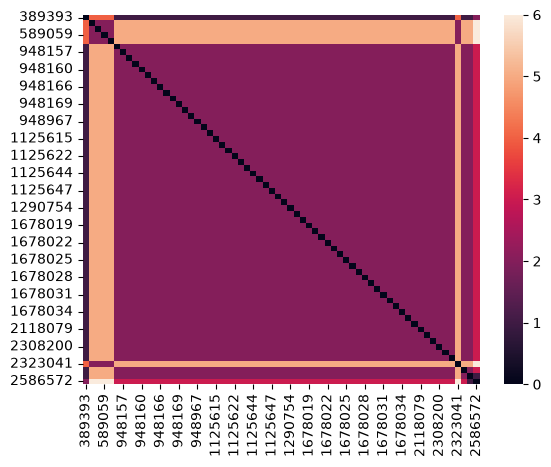

In [20]:
import seaborn as sns
sns.heatmap(
    rv_c["taxon"].apply(lambda a: rv_c["taxon"].apply(lambda b: tu.get_distance(a, b)))
)

## Tree topology
We can look at topology metrics from the tree with tu.topology, either passing a single taxon or a list of taxa to returns subtree topology metrics such as taxon count, leaf fraction, depth, branchiness, and `topology_scale`. Pass `anchor_rank="F"` to summarize the nearest family-level ancestor (or any other rank as anchor). A single taxon returns a Series; a list, array, or Series returns a DataFrame. See the README.md for a description of each column.

In [21]:
import pandas as pd
display(
  pd.concat(
      [tu.topology(11320).rename("exact_taxon"),
      tu.topology(11320, anchor_rank="F").rename("genus_anchor")],
      axis=1,
  )
)

,exact_taxon,genus_anchor
taxon,11320,11320
name,Influenza A virus,Influenza A virus
rank_code,S2,S2
anchor_taxon,11320,11308
anchor_name,Influenza A virus,Orthomyxoviridae
anchor_rank_code,S2,F
n_taxa,112717,131894
n_leaves,112563,131701
max_depth,3,6
mean_depth,1.998971,4.850061


In [22]:
tu.topology(11320, stat="topology_scale", anchor_rank="F")

5

In [23]:
tu.topology(tu.nodes.loc[tu.nodes["rank_code"] == "S", "taxon"][:5], anchor_rank="G")

,taxon,name,rank_code,anchor_taxon,anchor_name,anchor_rank_code,n_taxa,n_leaves,max_depth,mean_depth,topology_scale,max_children,branching_taxa_fraction,top_child_fraction
0,7,Azorhizobium caulinodans,S,6,Azorhizobium,G,104,99,2,1.932692,2,95,0.048077,0.932039
1,9,Buchnera aphidicola,S,32199,Buchnera,G,600,589,3,2.018333,2,511,0.018333,0.881469
2,11,Cellulomonas gilvus,S,1707,Cellulomonas,G,632,614,2,1.914557,2,559,0.028481,0.887480
3,14,Dictyoglomus thermophilum,S,13,Dictyoglomus,G,21,16,2,1.714286,2,13,0.238095,0.700000
4,17,Methylophilus methylotrophus,S,16,Methylophilus,G,79,75,2,1.822785,2,57,0.050633,0.743590


## Target Taxa

In ZarLab, we are working on metagenomics in the clinical setting, with the goal of creating an "agnostic diagnostic". We often want to look at broad array of taxa that could cause harm to people. In June 2024, CZI did the work of compiling a list of [pathogenic taxa](https://czid.org/pathogen_list). I did the easy work of turning this into a json and uploading it to my website, so that it is available and easily accessed for all time (in case that link ever breaks). taxutils will extend the taxa list to include subtrees of each of those pathogenic taxa. It will additionally include SARS-CoV2, since it was excluded from CZI's list. If you find any other obvious, missing pathogens, please send me a note, so I can update my json. You can also update the target_taxa member variable yourself, or store an entirely different set of targets, if you wanted.

In [24]:
display(tu.nodes[((tu.nodes["taxon"].isin(tu.target_taxa))&(tu.nodes["rank_base"]=="S"))])

,taxon,parent,rank,rank_code,rank_base,rank_idx,new_rank,name
104,139,64895,species,S,S,9,species,Borreliella burgdorferi
105,140,138,species,S,S,9,species,Borrelia hermsii
106,141,138,species,S,S,9,species,Borrelia parkeri
107,142,138,species,S,S,9,species,Borrelia turicatae
121,158,157,species,S,S,9,species,Treponema denticola
...,...,...,...,...,...,...,...,...
2720395,3479527,5061,forma,S2,S,9,species,Aspergillus niger f. hennebergii
2723244,3680471,582,subspecies,S2,S,9,species,Morganella morganii subsp. intermedius
2723857,3681844,59201,no rank,S3,S,9,species,Salmonella enterica subsp. enterica serovar - ...
2724161,3682713,59203,no rank,S3,S,9,species,Salmonella enterica subsp. arizonae serovar -:...


## Pretty print taxonomic tree

Kraken2 introduces a nice output format for summarizing taxa count reports (kreports). This package replicates the printing of this tree for usage in other scenarios to visualize tree results. Minimal usage is provided to allow for flexibility:

In [25]:
tree_series = tu.format_tree([10259, 147711, 2697049])
display(tree_series.head())
print(tree_series.head().to_string())

taxon
1                          root
10239                 \tViruses
2559587           \t\tRiboviria
2732396     \t\t\tOrthornavirae
2732408    \t\t\t\tPisuviricota
Name: name, dtype: object

taxon
1                          root
10239                 \tViruses
2559587           \t\tRiboviria
2732396     \t\t\tOrthornavirae
2732408    \t\t\t\tPisuviricota


To reproduce counts like in the Kraken2 kreports (or any other values to show against taxa) you could do the following:

In [26]:
taxon_counts = {12059: 500, 147711: 120, 2697049: 80}

tree = tu.format_tree(taxon_counts.keys())

cumulative = {taxon: 0 for taxon in tree.index}
for taxon, count in taxon_counts.items():
    for parent_taxon in tu.get_branch(taxon):
        if parent_taxon in cumulative: cumulative[parent_taxon] += count

total = sum(taxon_counts.values())

ranks = tu.nodes.set_index("taxon")[["rank_code", "new_rank", "rank"]]

df = tree.to_frame("name")
df["pct"] = [round(100 * cumulative[t] / total, 2) if total else 0 for t in df.index]
df["cumulative_count"] = [cumulative[t] for t in df.index]
df["count"] = [taxon_counts.get(t, 0) for t in df.index]
df = df.join(ranks).fillna({"rank_code": "U", "new_rank": "U", "rank": "U"})
df["taxon"] = df.index
df = df[["pct", "cumulative_count", "count", "rank_code", "new_rank", "rank", "taxon", "name"]]

df = df[["pct", "cumulative_count", "count", "rank_code", "new_rank", "rank", "taxon", "name"]]
df.to_csv("eg.kreport", index=False)

# check that the hierarchy was preserved correctly with the lca
print(tu.names[tu.get_lca(147711, 2697049)])

display(df)

Pisoniviricetes


,pct,cumulative_count,count,rank_code,new_rank,rank,taxon,name
taxon,,,,,,,,
1,100.00,700,0,R,root,no rank,1,root
10239,100.00,700,0,R2,root,acellular root,10239,\tViruses
2559587,100.00,700,0,D,domain,realm,2559587,\t\tRiboviria
2732396,100.00,700,0,K,kingdom,kingdom,2732396,\t\t\tOrthornavirae
2732408,100.00,700,0,P,phylum,phylum,2732408,\t\t\t\tPisuviricota
2732506,100.00,700,0,C,class,class,2732506,\t\t\t\t\tPisoniviricetes
76804,11.43,80,0,O,order,order,76804,\t\t\t\t\t\tNidovirales
2499399,11.43,80,0,O2,order,suborder,2499399,\t\t\t\t\t\t\tCornidovirineae
11118,11.43,80,0,F,family,family,11118,\t\t\t\t\t\t\t\tCoronaviridae
